# Building Our First Neural Network

Today we will build a Narrow AI system that learns to recognize handwritten digits.

Instead of programming rules like:
"If pixel looks like a curve → maybe a 3"

we will train a neural network to learn patterns directly from data.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [ ]:
def load_idx(filename):
    with open(filename, 'rb') as f:
        zero1, zero2, data_type, dims = np.frombuffer(f.read(4), dtype=np.uint8)
        
        shape = tuple(np.frombuffer(f.read(4*dims), dtype='>i4'))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)
    return data

In [ ]:
X_train = load_idx('/kaggle/input/mnist-dataset/train-images.idx3-ubyte')
y_train = load_idx('/kaggle/input/mnist-dataset/train-labels.idx1-ubyte')

X_test = load_idx('/kaggle/input/mnist-dataset/t10k-images.idx3-ubyte')
y_test = load_idx('/kaggle/input/mnist-dataset/t10k-labels.idx1-ubyte')

print(f"Train shapes: {X_train.shape}, {y_train.shape}")
print(f"Test shapes:  {X_test.shape}, {y_test.shape}")

In [ ]:
plt.figure(figsize=(8,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')


plt.show()


In [ ]:
#print("Shape of one image:", X_train[0].shape)
#print(X_train[0])

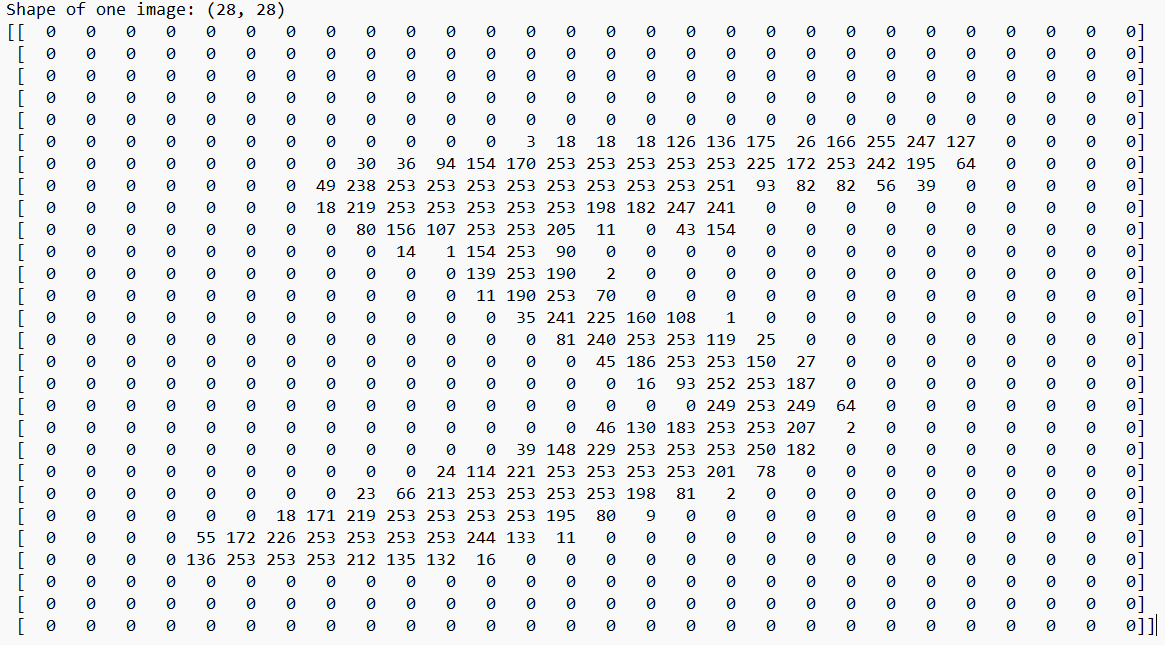

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

print("Original Shape:", X_train.shape)
print("Flattened shape:", X_train_flat.shape)


In [ ]:
X_train = torch.tensor(X_train_flat, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test_flat, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [ ]:
model = nn.Sequential(
    nn.Linear(784, 128),     
    nn.ReLU(),               
    nn.Linear(128, 10),      
    nn.LogSoftmax(dim=1)     
)

criterion = nn.NLLLoss()

In [ ]:
epochs = 5
learning_rate = 0.01

print(f"Training on {len(X_train)} samples...")

for epoch in range(epochs):

    outputs = model(X_train)
    
    loss = criterion(outputs, y_train)
    
    model.zero_grad()  
    loss.backward()    

    
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

In [ ]:
model.eval()

with torch.no_grad():
    
    test_outputs = model(X_test)
    
    predictions = torch.argmax(test_outputs, dim=1)
    
    correct_counts = (predictions == y_test).sum().item()
    accuracy = correct_counts / len(y_test)

    print(f"\nFinal Test Accuracy: {accuracy*100:.2f}%")

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[i].view(28,28), cmap='gray')
    plt.title(f"Pred: {predictions[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.show()